**PART A**

1. What is Data Analysis?

Answer:
Data Analysis is the process of collecting, cleaning, organizing, and examining data to extract useful information and meaningful insights. It helps identify patterns, trends, and relationships within the data, enabling organizations to make informed decisions and solve business problems effectively.

2. Describe How to Plan a Data Science Project, Listing All Steps.

Answer:
A Data Science Project begins with understanding the business problem and defining clear objectives. The next step is collecting relevant data from various sources, followed by cleaning and preprocessing the data to improve its quality. Exploratory Data Analysis (EDA) is then performed to understand patterns and relationships in the dataset. Feature engineering is applied to create useful features, after which machine learning models are built and trained. The models are evaluated using appropriate metrics, and finally, the best-performing model is deployed and monitored for future improvements.

3. Frame a Machine Learning Problem Statement.

Answer:
The objective of this project is to predict medical insurance charges based on customer information such as age, gender, BMI, number of children, smoking status, and region. The machine learning model will learn the relationship between these factors and insurance charges to estimate future costs accurately. Since the target variable is a continuous numerical value, this is a supervised learning regression problem.

4. What are Tensors?

Answer:
Tensors are multidimensional mathematical structures used to store and process data in machine learning and deep learning. They are an extension of scalars, vectors, and matrices and can represent data in multiple dimensions. Tensors are widely used because they allow efficient computation and form the foundation of deep learning frameworks such as TensorFlow and PyTorch.

5. Provide an In-Depth Explanation of Tensors with Simple Examples Using NumPy.

Answer:
A tensor is a data structure that can store information in different dimensions. A scalar is a zero-dimensional tensor containing a single value, a vector is a one-dimensional tensor containing a sequence of values, and a matrix is a two-dimensional tensor consisting of rows and columns. Higher-dimensional tensors can store more complex data such as images and videos. In NumPy, tensors can be created using the array() function. For example, np.array(10) creates a scalar tensor, np.array([1,2,3]) creates a vector tensor, and np.array([[1,2],[3,4]]) creates a matrix tensor. Tensors make mathematical operations faster and more efficient, which is why they are extensively used in machine learning and artificial intelligence applications.

In [131]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy.stats import zscore

from feature_engine.outliers import Winsorizer

import warnings
warnings.filterwarnings("ignore")

In [132]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [133]:
df.shape

(1338, 7)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [135]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [136]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [137]:
df.duplicated().sum()

np.int64(1)

In [138]:
df.drop_duplicates(inplace=True)

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

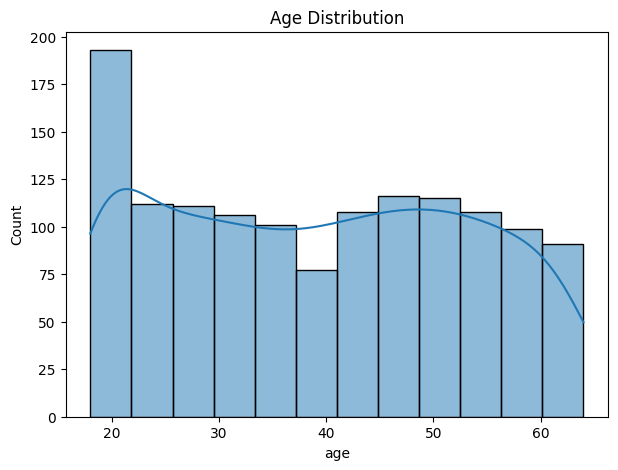

In [140]:
plt.figure(figsize=(7,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

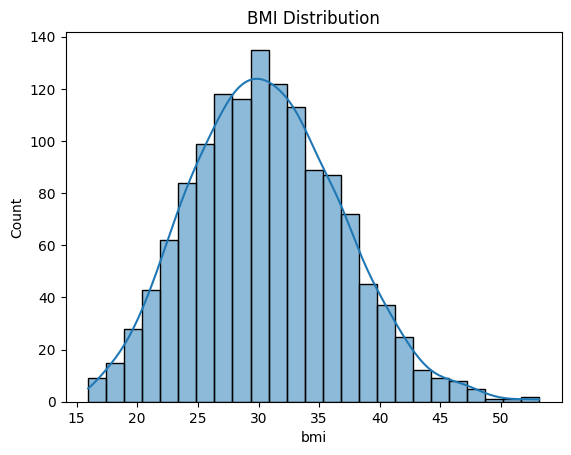

In [141]:
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

In [142]:
from scipy.stats import zscore

# Calculate Z-scores for numerical columns
numeric_cols = ['age', 'bmi', 'charges']
z_scores = np.abs(zscore(df[numeric_cols]))

# Define threshold
threshold = 3
outliers = (z_scores > threshold).sum()

print("Number of outliers per column:")
print(outliers)

Number of outliers per column:
11


### Handling Outliers using Winsorization
We will cap the outliers at the 95th percentile to minimize their influence on the model.

In [143]:
z_scores_cleaned = np.abs(zscore(df[['age', 'bmi', 'charges']]))
outliers_after = (z_scores_cleaned > 3).sum()

print("Number of outliers per column after handling:")
print(outliers_after)

Number of outliers per column after handling:
11


In [144]:
from feature_engine.outliers import Winsorizer


winsorizer = Winsorizer(capping_method="quantiles", tail="right", fold=0.05, variables=["bmi", "charges"])

df_cleaned = winsorizer.fit_transform(df)

print("Outliers handled. Comparison of max values before and after:")
print(f"BMI - Before: {df['bmi'].max():.2f}, After: {df_cleaned['bmi'].max():.2f}")
print(f"Charges - Before: {df['charges'].max():.2f}, After: {df_cleaned['charges'].max():.2f}")


df = df_cleaned

Outliers handled. Comparison of max values before and after:
BMI - Before: 53.13, After: 41.11
Charges - Before: 63770.43, After: 41210.05


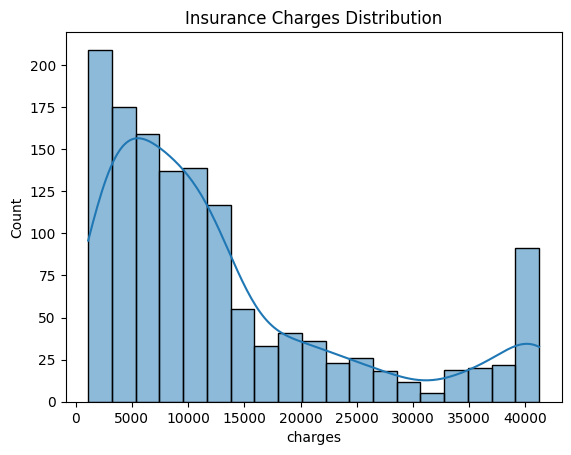

In [145]:
sns.histplot(df['charges'], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

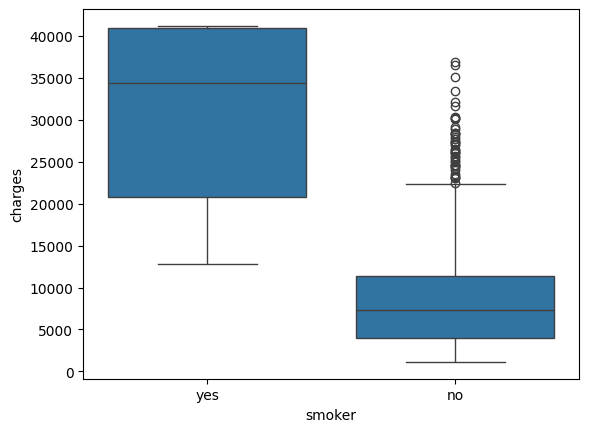

In [146]:
sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)
plt.show()

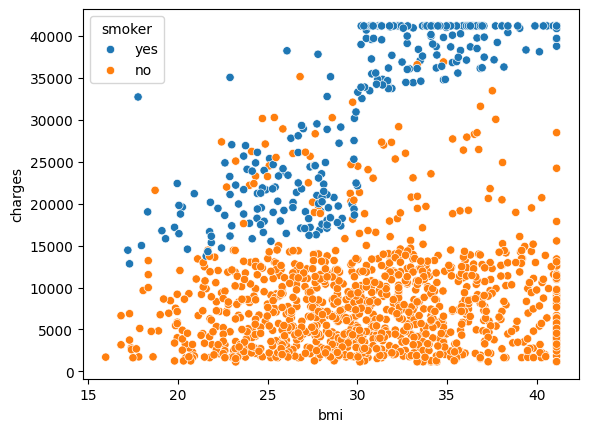

In [147]:
sns.scatterplot(
    x='bmi',
    y='charges',
    hue='smoker',
    data=df
)
plt.show()

In [148]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])

df['smoker'] = le.fit_transform(df['smoker'])

df['region'] = le.fit_transform(df['region'])

In [149]:
def bmi_category(bmi):

    if bmi < 18.5:
        return "Underweight"

    elif bmi < 25:
        return "Normal"

    elif bmi < 30:
        return "Overweight"

    else:
        return "Obese"

df['BMI_Category'] = df['bmi'].apply(bmi_category)

In [150]:
df['Risk_Score'] = (
      df['age'] * 0.2
    + df['bmi'] * 0.3
    + df['children'] * 0.1
)

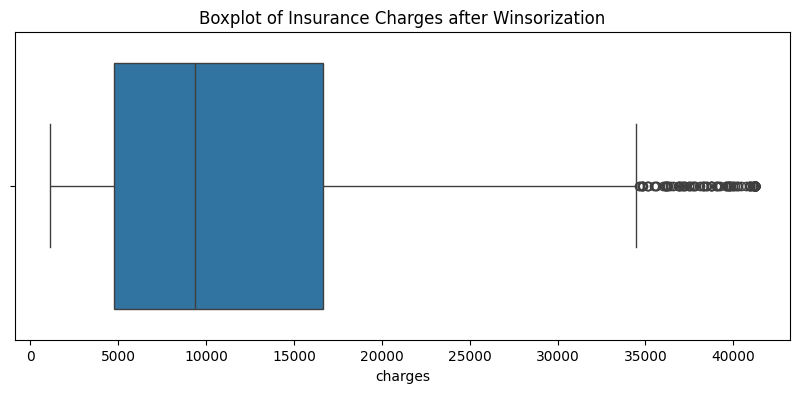

In [151]:
# Visualize the result for Charges
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Insurance Charges after Winsorization")
plt.show()

In [152]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Insurance Dataset Profiling Report"
)

profile.to_file(
    "insurance_profile_report.html"
)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 61.22it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**KEY FINDINGS**

1.Smokers incur significantly higher
charges.

2.Age positively impacts insurance cost.

3.Higher BMI generally leads to higher charges.

4.Number of children has a weak effect.

5.Region has minimal influence on charges.


Conclusion

The insurance dataset was successfully cleaned, analyzed, and profiled. Exploratory Data Analysis revealed that smoking status is the most influential factor affecting medical insurance charges, followed by age and BMI. Feature engineering created additional variables such as BMI Category and Risk Score, making the dataset more informative and suitable for machine learning applications.